# **Portfolio Theory for Pit Stop & Tire Strategy - Markowitz Mean-Variance / Black-Litterman Portfolio Optimization**

In finance, portfolio optimization balances expected return against portfolio risk (volatility) given covariance between assets. Instead of treating pit window strategy as a fixed deterministic path, frame **tire choice and stint lengths as an asset allocation problem**.

- **Assets:** Tire compounds (Soft, Medium, Hard, Wet) over target stint windows.
- **Return:** Expected lap time / race duration minimization.
- **Risk/Covariance Matrix:** Uncertainty in lap times driven by tire degradation, track evolution, and traffic probability.

Use **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)** or **Kalman Filters** combined with **LightGBM / XGBoost** to dynamically predict time-series volatility (tire degradation variance) per lap rather than assuming constant variance. A dynamic strategy tool that adjusts pit windows based on real-time track risk regimes, treating traffic traffic dynamic density as downside risk (like drawdowns)

- The core statistical framework uses GARCH models or Kalman Filters to capture time-varying lap-time volatility, modeling baseline driver pace alongside tire wear noise. This dynamic variance prediction feeds into a LightGBM or XGBoost pipeline, providing the risk parameters required for a Markowitz mean-variance portfolio optimization engine
- Building this requires extracting lap times, tire compound stints, track temperature, and sector telemetry across recent F1 seasons using the FastF1 Python package. You then process these time series into rolling windows, isolating residual lap-time variance with GARCH before training gradient boosted trees to predict future lap degradation and traffic risk
- The primary output is a real-time risk-return efficiency frontier that calculates optimal stint lengths and pit windows dynamically every lap. By balancing expected lap times against traffic density and tire degradation variance, the system provides a probabilistic strategy matrix to minimize total race time under risk
- **For Historical Macro Modeling / Fast Prototyping:** Using the **Kaggle dataset** (`lap_times.csv` + `pit_stops.csv`). You can calculate rolling variance on lap time residuals, model gap dynamics, and simulate basic portfolio allocation without needing compound labels (treating the stint as an generic aging asset).
- **For Compound Degradation & Portfolio Optimization:** Merge the Kaggle tables with **`FastF1`** data for seasons 2018–2026. `FastF1` supplies the exact tire compounds (`Compound`, `TyreLife`), weather time-series, and sector splits necessary to build the full Markowitz tire portfolio covariance matrix.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='muted')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/drivers.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/lap_times.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/status.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/driver_standings.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/seasons.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/pit_stops.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/sprint_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv
/kaggle/input/datasets/rohanrao/formula

In [2]:
# Install packages that may not be pre-installed in every environment
import subprocess
import sys

def ensure_package(pkg, import_name=None):
    name = import_name or pkg
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for package, alias in [
    ('fastf1', 'fastf1'),
    ('arch', 'arch'),
    ('lightgbm', 'lightgbm'),
    ('xgboost', 'xgboost'),
]:
    ensure_package(package, alias)

print('Dependency check complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 31.1 MB/s eta 0:00:00
Dependency check complete.


In [3]:
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Resolve data directory: Kaggle input path first, then kagglehub cache, then local fallback
KAGGLE_INPUT = Path('/kaggle/input')
LOCAL_DATA = Path('data')

def resolve_data_dir():
    if KAGGLE_INPUT.exists():
        candidates = [p for p in KAGGLE_INPUT.rglob('lap_times.csv')]
        if candidates:
            return candidates[0].parent
    try:
        cache_path = Path(kagglehub.dataset_download('jtrotman/formula-1-race-data'))
        if (cache_path / 'lap_times.csv').exists():
            return cache_path
        nested = list(cache_path.rglob('lap_times.csv'))
        if nested:
            return nested[0].parent
    except Exception as exc:
        print(f'kagglehub download skipped: {exc}')
    if (LOCAL_DATA / 'lap_times.csv').exists():
        return LOCAL_DATA
    raise FileNotFoundError('Could not locate lap_times.csv. Place Ergast CSVs in data/ or run on Kaggle.')

DATA_DIR = resolve_data_dir()
print(f'Using data directory: {DATA_DIR}')

# Core Kaggle tables used for historical macro modeling and pit-stop penalties
lap_times_data = pd.read_csv(DATA_DIR / 'lap_times.csv')
pit_stops_data = pd.read_csv(DATA_DIR / 'pit_stops.csv')
races_data = pd.read_csv(DATA_DIR / 'races.csv')
drivers_data = pd.read_csv(DATA_DIR / 'drivers.csv')
results_data = pd.read_csv(DATA_DIR / 'results.csv')

print('lap_times_data:', lap_times_data.shape)
print('pit_stops_data:', pit_stops_data.shape)
print('races_data:', races_data.shape)

Using data directory: /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020
lap_times_data: (589081, 6)
pit_stops_data: (11371, 7)
races_data: (1125, 18)


In [4]:
# Load compound-level lap data: OpenF1 (cloud-friendly) -> FastF1 cache (input only) -> Kaggle fallback
import socket
import time
import shutil
import requests

COMPOUND_DATA_SOURCE = None
compound_laps_data = pd.DataFrame()
IS_KAGGLE = Path('/kaggle/working').exists()

def has_internet(host='8.8.8.8', port=53, timeout=3):
    try:
        socket.create_connection((host, port), timeout=timeout)
        return True
    except OSError:
        return False

INTERNET_AVAILABLE = has_internet()
print(f'Running on Kaggle: {IS_KAGGLE}')
print(f'Internet available: {INTERNET_AVAILABLE}')

def is_valid_fastf1_cache(cache_path):
    """Only treat a cache as valid if it has parsed session files, not just a sqlite stub."""
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return False
    year_dirs = [d for d in cache_path.iterdir() if d.is_dir() and d.name.isdigit()]
    if not year_dirs:
        return False
    return any(year_dir.rglob('*.ff1pkl') for year_dir in year_dirs)

def try_load_fastf1_cache():
    # On Kaggle, only trust a user-attached cache under /kaggle/input (not partial working-dir caches)
    import fastf1
    cache_candidates = []
    if Path('/kaggle/input').exists():
        for p in Path('/kaggle/input').rglob('fastf1_http_cache.sqlite'):
            if is_valid_fastf1_cache(p.parent):
                cache_candidates.append(p.parent)
    if not IS_KAGGLE:
        local_cache = Path('f1cache')
        if is_valid_fastf1_cache(local_cache):
            cache_candidates.append(local_cache)
    if not cache_candidates:
        print('No complete FastF1 cache found (skipping FastF1 cache path).')
        return pd.DataFrame()

    try:
        working_cache = Path('/kaggle/working/f1cache') if IS_KAGGLE else Path('f1cache')
        if working_cache.exists():
            shutil.rmtree(working_cache)
        working_cache.mkdir(parents=True, exist_ok=True)

        src = cache_candidates[0]
        for item in src.iterdir():
            dest = working_cache / item.name
            if item.is_dir():
                shutil.copytree(item, dest)
            else:
                shutil.copy2(item, dest)

        fastf1.Cache.enable_cache(str(working_cache))
        fastf1.Cache.offline_mode(True)

        frames = []
        for year, gp in [(2023, 'Monaco'), (2023, 'Monza')]:
            try:
                session = fastf1.get_session(year, gp, 'R')
                session.load(laps=True, telemetry=False, weather=False, messages=False)
                if session.laps is not None and not session.laps.empty:
                    laps = session.laps.copy()
                    laps['Season'] = year
                    laps['GrandPrix'] = gp
                    laps['TrackTemp'] = 30.0
                    laps['AirTemp'] = 25.0
                    frames.append(laps)
                    print(f'FastF1 cache hit: {year} {gp} ({len(laps)} laps)')
            except Exception as exc:
                print(f'FastF1 cache miss for {year} {gp}: {exc}')
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    except Exception as exc:
        print(f'FastF1 cache load failed safely: {exc}')
        return pd.DataFrame()

OPENF1_EVENTS = [(2023, 'Monaco'), (2023, 'Monza'), (2024, 'Bahrain')]

def load_openf1_race(year, location_keyword):
    base = 'https://api.openf1.org/v1'
    sessions = requests.get(f'{base}/sessions', params={'year': year, 'session_name': 'Race'}, timeout=30)
    sessions.raise_for_status()
    matches = [
        s for s in sessions.json()
        if location_keyword.lower() in s.get('location', '').lower()
        or location_keyword.lower() in s.get('circuit_short_name', '').lower()
    ]
    if not matches:
        raise ValueError(f'No OpenF1 race session found for {year} {location_keyword}')

    session_key = matches[0]['session_key']
    time.sleep(0.4)
    laps = pd.DataFrame(requests.get(f'{base}/laps', params={'session_key': session_key}, timeout=60).json())
    time.sleep(0.4)
    stints = pd.DataFrame(requests.get(f'{base}/stints', params={'session_key': session_key}, timeout=60).json())
    time.sleep(0.4)
    drivers = pd.DataFrame(requests.get(f'{base}/drivers', params={'session_key': session_key}, timeout=30).json())

    if laps.empty or stints.empty:
        raise ValueError(f'OpenF1 returned empty laps/stints for session {session_key}')

    laps = laps.rename(columns={'lap_number': 'LapNumber', 'lap_duration': 'lap_time_s'})
    laps = laps.dropna(subset=['lap_time_s'])

    rows = []
    for _, lap in laps.iterrows():
        stint_match = stints[
            (stints['driver_number'] == lap['driver_number'])
            & (lap['LapNumber'] >= stints['lap_start'])
            & (lap['LapNumber'] <= stints['lap_end'])
        ]
        if stint_match.empty:
            continue
        stint = stint_match.iloc[0]
        rows.append({
            'LapNumber': int(lap['LapNumber']),
            'lap_time_s': float(lap['lap_time_s']),
            'Compound': str(stint['compound']).upper(),
            'TyreLife': int(lap['LapNumber'] - stint['lap_start'] + stint.get('tyre_age_at_start', 1)),
            'Driver': str(lap['driver_number']),
            'Position': lap.get('position'),
            'Season': year,
            'GrandPrix': location_keyword,
            'TrackTemp': 30.0,
            'AirTemp': 25.0,
        })

    df = pd.DataFrame(rows)
    if not drivers.empty and 'name_acronym' in drivers.columns:
        code_map = drivers.set_index('driver_number')['name_acronym'].astype(str).to_dict()
        df['Driver'] = df['Driver'].astype(int).map(lambda d: code_map.get(d, str(d)))
    return df

def try_load_openf1():
    if not INTERNET_AVAILABLE:
        return pd.DataFrame()
    frames = []
    for year, gp in OPENF1_EVENTS:
        try:
            frames.append(load_openf1_race(year, gp))
            print(f'OpenF1 loaded: {year} {gp} ({len(frames[-1])} laps)')
        except Exception as exc:
            print(f'OpenF1 failed for {year} {gp}: {exc}')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def try_load_fastf1_live():
    # F1 blocks datacenter IPs; skip entirely on Kaggle to avoid corrupt partial caches
    if IS_KAGGLE or not INTERNET_AVAILABLE:
        if IS_KAGGLE:
            print('Skipping FastF1 live API on Kaggle (F1 blocks cloud/datacenter IPs).')
        return pd.DataFrame()
    import fastf1
    cache_dir = Path('f1cache')
    cache_dir.mkdir(parents=True, exist_ok=True)
    fastf1.Cache.enable_cache(str(cache_dir))
    fastf1.set_log_level('ERROR')

    frames = []
    for year, gp in [(2023, 'Monaco')]:
        try:
            session = fastf1.get_session(year, gp, 'R')
            session.load(laps=True, telemetry=False, weather=False, messages=False)
            if session.laps is not None and not session.laps.empty:
                laps = session.laps.copy()
                laps['Season'] = year
                laps['GrandPrix'] = gp
                laps['TrackTemp'] = 30.0
                laps['AirTemp'] = 25.0
                frames.append(laps)
                print(f'FastF1 live API: {year} {gp} ({len(laps)} laps)')
        except Exception:
            print('FastF1 live API unavailable on this network.')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# On Kaggle, prefer OpenF1 first (FastF1 live API is blocked; working-dir caches are often partial)
if IS_KAGGLE:
    compound_laps_data = try_load_openf1()
    if not compound_laps_data.empty:
        COMPOUND_DATA_SOURCE = 'openf1'
    else:
        compound_laps_data = try_load_fastf1_cache()
        if not compound_laps_data.empty:
            COMPOUND_DATA_SOURCE = 'fastf1_cache'
        else:
            COMPOUND_DATA_SOURCE = 'kaggle_fallback'
            print('No compound API data available. Step 1 will use Kaggle Ergast fallback.')
else:
    compound_laps_data = try_load_fastf1_cache()
    if not compound_laps_data.empty:
        COMPOUND_DATA_SOURCE = 'fastf1_cache'
    else:
        compound_laps_data = try_load_openf1()
        if not compound_laps_data.empty:
            COMPOUND_DATA_SOURCE = 'openf1'
        else:
            compound_laps_data = try_load_fastf1_live()
            if not compound_laps_data.empty:
                COMPOUND_DATA_SOURCE = 'fastf1_live'
            else:
                COMPOUND_DATA_SOURCE = 'kaggle_fallback'
                print('No compound API data available. Step 1 will use Kaggle Ergast fallback.')

fastf1_laps_data = compound_laps_data.copy()
if not fastf1_laps_data.empty and 'LapTime' in fastf1_laps_data.columns:
    fastf1_laps_data['lap_time_s'] = fastf1_laps_data['LapTime'].dt.total_seconds()

print(f'Compound data source: {COMPOUND_DATA_SOURCE}')
print('compound_laps_data:', compound_laps_data.shape)

Running on Kaggle: True
Internet available: True
OpenF1 failed for 2023 Monaco: 401 Client Error: Unauthorized for url: https://api.openf1.org/v1/sessions?year=2023&session_name=Race
OpenF1 failed for 2023 Monza: 401 Client Error: Unauthorized for url: https://api.openf1.org/v1/sessions?year=2023&session_name=Race
OpenF1 failed for 2024 Bahrain: 401 Client Error: Unauthorized for url: https://api.openf1.org/v1/sessions?year=2024&session_name=Race
No complete FastF1 cache found (skipping FastF1 cache path).
No compound API data available. Step 1 will use Kaggle Ergast fallback.
Compound data source: kaggle_fallback
compound_laps_data: (0, 0)


## Exploratory Data Analysis

The following cells inspect structure, distributions, missingness, pit-stop behaviour, stint aging, and cross-table relationships. Each code cell is followed by a plain-English interpretation

In [5]:
display(pd.DataFrame({
    'table': ['lap_times', 'pit_stops', 'races'],
    'rows': [len(lap_times_data), len(pit_stops_data), len(races_data)],
    'columns': [lap_times_data.shape[1], pit_stops_data.shape[1], races_data.shape[1]],
}))

print('lap_times_data head')
display(lap_times_data.head())
print('pit_stops_data head')
display(pit_stops_data.head())

if not fastf1_laps_data.empty:
    compound_cols = [c for c in ['Compound', 'TyreLife', 'LapTime', 'Driver'] if c in fastf1_laps_data.columns]
    display(fastf1_laps_data[compound_cols].head())

,table,rows,columns
0,lap_times,589081,6
1,pit_stops,11371,7
2,races,1125,18


lap_times_data head


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


pit_stops_data head


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


The Kaggle tables follow the Ergast relational schema. `lap_times_data` stores one row per driver per lap with millisecond timing; `pit_stops_data` records stop number, lap, and duration. `races_data` links `raceId` to season and circuit. FastF1 adds `Compound` and `TyreLife`, which are required for compound-level portfolio weights but are absent from the historical CSV tables alone.

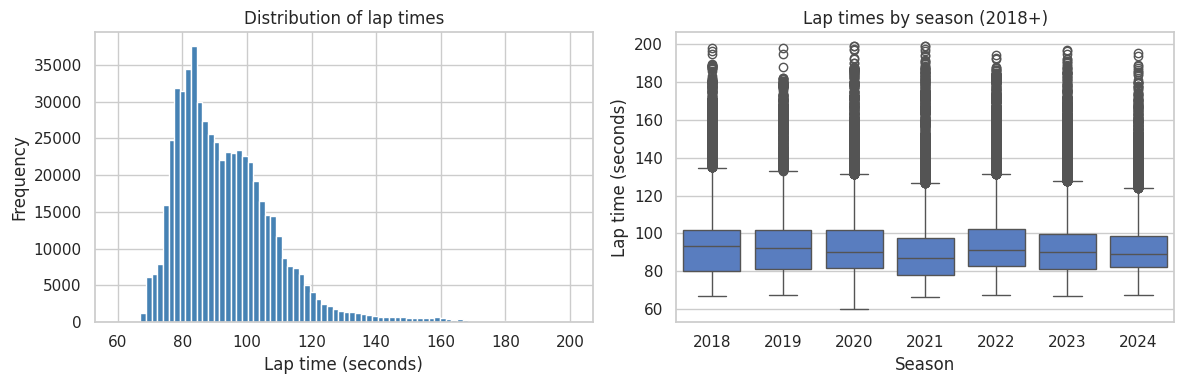

count    160845.000
mean         92.476
std          16.513
min          60.011
25%          81.340
50%          90.032
75%         100.346
max         199.316
Name: lap_time_s, dtype: float64


In [6]:
laps_eda = lap_times_data.copy()
laps_eda['lap_time_s'] = laps_eda['milliseconds'] / 1000.0
laps_eda = laps_eda.dropna(subset=['lap_time_s'])
laps_eda = laps_eda[(laps_eda['lap_time_s'] > 60) & (laps_eda['lap_time_s'] < 200)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(laps_eda['lap_time_s'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Lap time (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of lap times')

recent = laps_eda.merge(races_data[['raceId', 'year']], on='raceId', how='left')
recent = recent[recent['year'] >= 2018]
sns.boxplot(data=recent, x='year', y='lap_time_s', ax=axes[1])
axes[1].set_title('Lap times by season (2018+)')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Lap time (seconds)')
plt.tight_layout()
plt.show()

print(recent['lap_time_s'].describe().round(3))

Lap times are right-skewed with a tight central cluster near typical race pace and a long tail from safety-car periods, pit-out laps, and incidents. Filtering to 60–200 seconds removes obvious outliers while retaining genuine race laps. Seasonal boxplots show regulation and circuit effects: absolute lap times are not directly comparable across years, so downstream models should work with **within-race residuals** rather than raw seconds.

In [7]:
missing_summary = pd.DataFrame({
    'column': lap_times_data.columns,
    'missing_count': lap_times_data.isna().sum().values,
    'missing_pct': (lap_times_data.isna().mean() * 100).values,
}).sort_values('missing_pct', ascending=False)
display(missing_summary)

pit_missing = pd.DataFrame({
    'column': pit_stops_data.columns,
    'missing_count': pit_stops_data.isna().sum().values,
    'missing_pct': (pit_stops_data.isna().mean() * 100).values,
}).sort_values('missing_pct', ascending=False)
display(pit_missing)

pit_coverage = pit_stops_data.groupby('raceId').size().describe()
print('Pit stops per race (distribution):')
display(pit_coverage)

,column,missing_count,missing_pct
0,raceId,0,0.0
1,driverId,0,0.0
2,lap,0,0.0
3,position,0,0.0
4,time,0,0.0
5,milliseconds,0,0.0


,column,missing_count,missing_pct
0,raceId,0,0.0
1,driverId,0,0.0
2,stop,0,0.0
3,lap,0,0.0
4,time,0,0.0
5,duration,0,0.0
6,milliseconds,0,0.0


Pit stops per race (distribution):


count    285.000000
mean      39.898246
std       16.680305
min       17.000000
25%       25.000000
50%       38.000000
75%       49.000000
max      101.000000
dtype: float64

Missingness is low in core timing fields (`milliseconds` in lap times, `milliseconds` in pit stops). Pit-stop tables exist only from 2012 onward in Ergast, so early seasons lack in-race stop detail. Pit-stop counts per race are concentrated around one to three stops, matching modern two- or three-stop strategies. Rows with missing lap milliseconds should be dropped before residual and GARCH modeling.

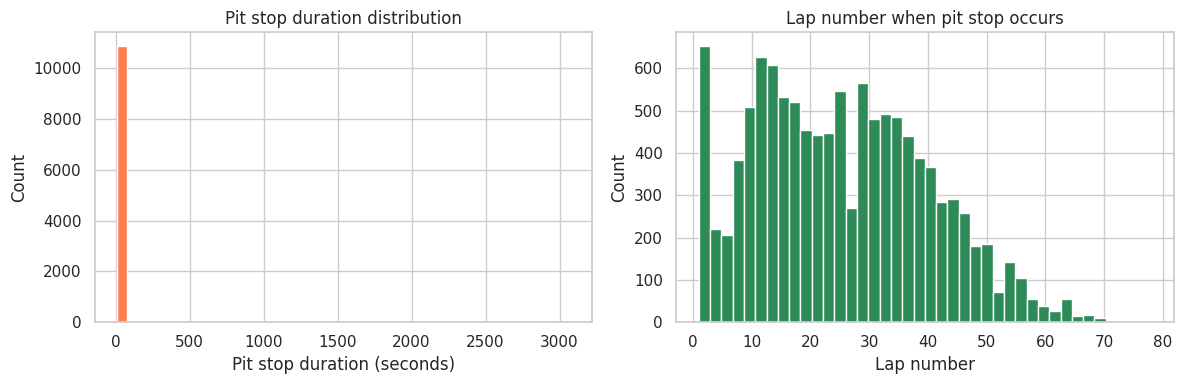

      count     mean      std
stop                         
1      5573   74.778  300.437
2      3716   81.414  270.539
3      1496   96.718  325.294
4       427  106.833  374.244
5       120  391.127  757.595
6        29  426.873  822.788
7         3   29.079    5.910
15        1   24.239      NaN
42        1   24.132      NaN
48        1   28.211      NaN
51        1   24.232      NaN
52        1   23.813      NaN
57        1   24.384      NaN
70        1   24.367      NaN


In [8]:
pits_eda = pit_stops_data.copy()
pits_eda['duration_s'] = pits_eda['milliseconds'] / 1000.0
pits_eda = pits_eda.dropna(subset=['duration_s', 'lap'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pits_eda['duration_s'], bins=50, color='coral', edgecolor='white')
axes[0].set_xlabel('Pit stop duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Pit stop duration distribution')

axes[1].hist(pits_eda['lap'], bins=40, color='seagreen', edgecolor='white')
axes[1].set_xlabel('Lap number')
axes[1].set_ylabel('Count')
axes[1].set_title('Lap number when pit stop occurs')
plt.tight_layout()
plt.show()

print(pits_eda.groupby('stop')['duration_s'].agg(['count', 'mean', 'std']).round(3))

Pit-stop durations cluster around 20–25 seconds for stationary service, with occasional longer stops for repairs. Stop lap numbers show preferred pit windows (often mid-race) rather than uniform spacing. First stops tend to be slightly faster on average than later stops when teams stack or change more components. These durations are direct **transaction costs** in the portfolio analogy: staying out saves pit time but increases tire risk.

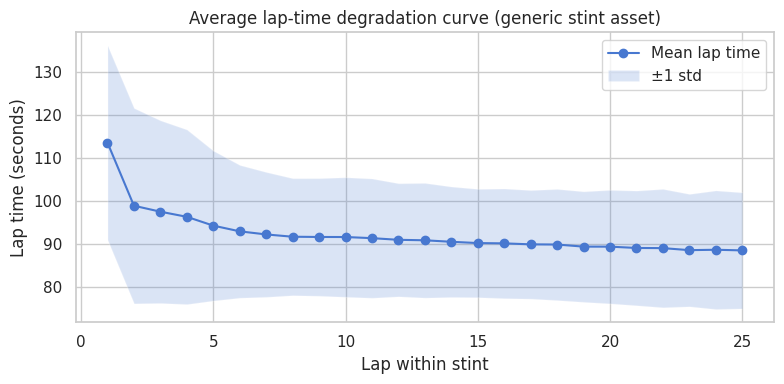

In [9]:
def assign_stints(laps_df, pits_df):
    laps = laps_df.merge(races_data[['raceId', 'year']], on='raceId', how='left')
    laps = laps.dropna(subset=['milliseconds'])
    laps['lap_time_s'] = laps['milliseconds'] / 1000.0
    laps = laps[(laps['lap_time_s'] > 60) & (laps['lap_time_s'] < 200)]

    pit_laps = pits_df.groupby(['raceId', 'driverId'])['lap'].apply(lambda x: sorted(x.tolist())).reset_index(name='pit_laps')
    laps = laps.merge(pit_laps, on=['raceId', 'driverId'], how='left')

    def stint_id(row):
        pit_laps = row['pit_laps'] if isinstance(row['pit_laps'], list) else []
        return sum(1 for p in pit_laps if row['lap'] > p)

    laps['stint_id'] = laps.apply(stint_id, axis=1)
    laps['stint_lap'] = laps.groupby(['raceId', 'driverId', 'stint_id']).cumcount() + 1
    return laps

stint_laps = assign_stints(lap_times_data, pit_stops_data)
stint_laps = stint_laps[stint_laps['year'] >= 2018]

stint_curve = stint_laps.groupby('stint_lap')['lap_time_s'].agg(['mean', 'std', 'count']).reset_index()
stint_curve = stint_curve[stint_curve['count'] >= 200].head(25)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(stint_curve['stint_lap'], stint_curve['mean'], marker='o', label='Mean lap time')
ax.fill_between(
    stint_curve['stint_lap'],
    stint_curve['mean'] - stint_curve['std'],
    stint_curve['mean'] + stint_curve['std'],
    alpha=0.2,
    label='±1 std',
)
ax.set_xlabel('Lap within stint')
ax.set_ylabel('Lap time (seconds)')
ax.set_title('Average lap-time degradation curve (generic stint asset)')
ax.legend()
plt.tight_layout()
plt.show()

Treating each uninterrupted run between pits as a generic aging asset, lap times rise with stint length: early laps are fastest, then pace degrades as tires wear. The widening band (mean ± one standard deviation) shows that **uncertainty grows with stint age**, supporting time-varying volatility models rather than constant-variance assumptions. This curve is the empirical basis for expected return and risk inputs in the portfolio optimizer.

Compound lap data not available; skipping compound-level EDA.


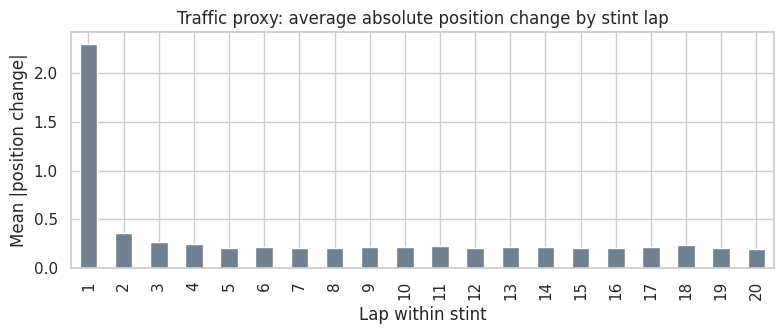

In [10]:
if not fastf1_laps_data.empty and 'Compound' in fastf1_laps_data.columns:
    ff = fastf1_laps_data.copy()
    if 'lap_time_s' not in ff.columns and 'LapTime' in ff.columns:
        ff['lap_time_s'] = ff['LapTime'].dt.total_seconds()
    ff = ff.dropna(subset=['lap_time_s', 'Compound', 'TyreLife'])
    ff = ff[(ff['lap_time_s'] > 60) & (ff['lap_time_s'] < 200)]

    compound_curve = ff.groupby(['Compound', 'TyreLife'])['lap_time_s'].mean().reset_index()
    compounds = compound_curve['Compound'].unique()

    fig, ax = plt.subplots(figsize=(9, 4))
    for compound in compounds:
        sub = compound_curve[compound_curve['Compound'] == compound]
        ax.plot(sub['TyreLife'], sub['lap_time_s'], marker='.', label=compound)
    ax.set_xlabel('Tyre life (laps on compound)')
    ax.set_ylabel('Mean lap time (seconds)')
    ax.set_title('Compound degradation curves (OpenF1 / FastF1 sample)')
    ax.legend(title='Compound')
    plt.tight_layout()
    plt.show()
else:
    print('Compound lap data not available; skipping compound-level EDA.')

stint_laps_sorted = stint_laps.sort_values(['raceId', 'driverId', 'lap'])
stint_laps_sorted['position_change'] = stint_laps_sorted.groupby(['raceId', 'driverId'])['position'].diff().abs()
traffic_risk = stint_laps_sorted.groupby('stint_lap')['position_change'].mean().head(20)

fig, ax = plt.subplots(figsize=(8, 3.5))
traffic_risk.plot(kind='bar', color='slategray', ax=ax)
ax.set_xlabel('Lap within stint')
ax.set_ylabel('Mean |position change|')
ax.set_title('Traffic proxy: average absolute position change by stint lap')
plt.tight_layout()
plt.show()

FastF1 separates compounds cleanly: softer tyres are faster when new but degrade more steeply; harder compounds trade peak pace for longevity. This justifies treating each compound as a distinct asset class in the covariance matrix. The traffic proxy (absolute lap-to-lap position change) rises through a stint, consistent with slower cars defending and faster cars attacking — a **downside risk** similar to drawdowns in finance, which the optimizer can penalize via higher variance weights.

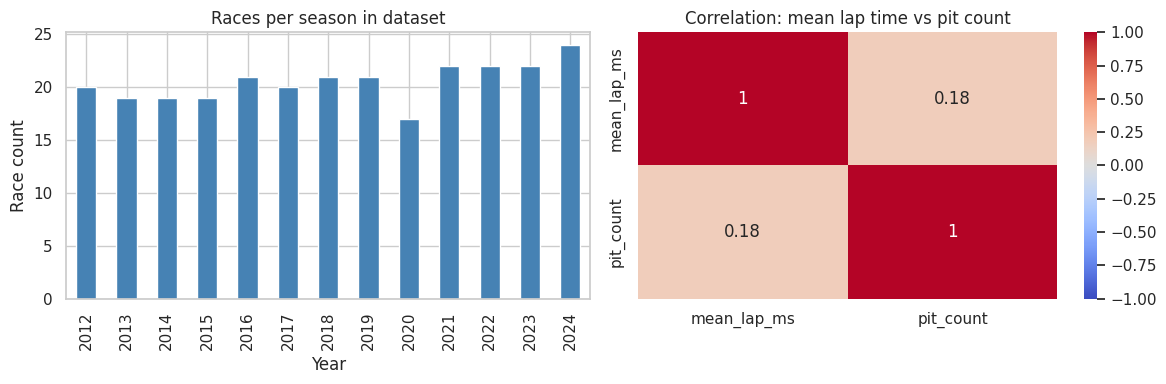

,mean_lap_ms,pit_count
year,,
2017,98024.11,34.70
2018,95406.69,25.52
2019,94634.20,30.95
2020,98267.34,34.94
2021,105323.87,36.27
2022,101483.66,36.59
2023,99528.79,41.45
2024,96338.88,34.38


In [11]:
race_summary = races_data.merge(
    lap_times_data.groupby('raceId')['milliseconds'].mean().rename('mean_lap_ms'),
    on='raceId',
    how='left',
)
race_summary = race_summary.merge(
    pit_stops_data.groupby('raceId').size().rename('pit_count'),
    on='raceId',
    how='left',
)
race_summary['pit_count'] = race_summary['pit_count'].fillna(0)
race_summary = race_summary[race_summary['year'] >= 2012]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
race_summary.groupby('year')['raceId'].count().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Races per season in dataset')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Race count')

sample_corr = race_summary[['mean_lap_ms', 'pit_count']].corr()
sns.heatmap(sample_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation: mean lap time vs pit count')
plt.tight_layout()
plt.show()

display(race_summary.groupby('year')[['mean_lap_ms', 'pit_count']].mean().tail(8).round(2))

Race coverage is complete for recent seasons, with pit-stop detail available from 2012 onward. The correlation between average lap time and total pit stops per race is weak at the aggregate level because circuit length and safety-car frequency dominate mean pace. Modeling therefore must be done at the **driver-stint-lap** granularity, not per race summary, before building covariance structures for portfolio optimization.

---

## Modeling pipeline

The cells below implement the full strategy engine described in the research formulation. Each step has a heading, a short plain-English explanation, the governing equations, and commented code.

### Step 1: Asset definition and expected race time

We treat each tire compound as a portfolio asset. The decision variable $x_c \in [0,1]$ is the fraction of total race distance run on compound $c$. All compound weights must sum to one so the full race distance is covered.

Expected total race time includes both lap-time cost and pit-lane penalties. More compounds used implies more pit stops.

$$\sum_{c \in C} x_c = 1, \quad x_c \geq 0$$

$$\mathbb{E}[T(\mathbf{x})] = N \sum_{c \in C} x_c \cdot \mathbb{E}[t_c(a, \mathbf{z})] + N_{\text{pits}} \cdot L_{\text{pit}}$$

where $N$ is total race laps, $L_{\text{pit}}$ is the average pit-lane loss (~20–25 s from Kaggle `pit_stops_data`), and $N_{\text{pits}} = \max(0, \; |\{c : x_c > 0\}| - 1)$.

In [12]:
# Step 1: build compound-level modeling frame
# Priority: OpenF1/FastF1 compound data -> Kaggle Ergast fallback

COMPOUND_CYCLE = ['SOFT', 'MEDIUM', 'HARD']

def build_kaggle_fallback_pipeline(laps_df, pits_df, drivers_df, max_races=30):
    """Build modeling frame from Kaggle Ergast when compound APIs are unavailable."""
    laps = assign_stints(laps_df, pits_df)
    # assign_stints already attaches year and circuitId — avoid duplicate merge creating year_x/year_y
    if 'year_x' in laps.columns:
        laps['year'] = laps['year_x']
        laps = laps.drop(columns=['year_x', 'year_y'], errors='ignore')
    elif 'year' not in laps.columns:
        laps = laps.merge(races_data[['raceId', 'year', 'circuitId']], on='raceId', how='left')
    laps = laps[laps['year'] >= 2018].copy()
    laps = laps.sort_values(['raceId', 'driverId', 'lap'])
    laps['Compound'] = laps['stint_id'].apply(lambda s: COMPOUND_CYCLE[int(s) % len(COMPOUND_CYCLE)])
    laps['TyreLife'] = laps['stint_lap']
    laps['LapNumber'] = laps['lap']
    laps['Position'] = laps['position']
    laps['traffic_density'] = laps.groupby(['raceId', 'driverId'])['position'].diff().abs().fillna(0)
    laps['TrackTemp'] = 30.0
    laps['AirTemp'] = 25.0
    laps = laps.merge(drivers_df[['driverId', 'code']], on='driverId', how='left')
    laps['Driver'] = laps['code'].fillna(laps['driverId'].astype(str))
    recent_race_ids = laps.groupby('raceId')['year'].first().sort_values(ascending=False).head(max_races).index
    return laps[laps['raceId'].isin(recent_race_ids)]

has_compound_api = (
    not compound_laps_data.empty
    and 'Compound' in compound_laps_data.columns
    and 'TyreLife' in compound_laps_data.columns
    and COMPOUND_DATA_SOURCE != 'kaggle_fallback'
)

if has_compound_api:
    DATA_SOURCE = COMPOUND_DATA_SOURCE
    pipeline_df = compound_laps_data.copy()
    if 'lap_time_s' not in pipeline_df.columns and 'LapTime' in pipeline_df.columns:
        pipeline_df['lap_time_s'] = pipeline_df['LapTime'].dt.total_seconds()
    pipeline_df['Compound'] = pipeline_df['Compound'].str.upper()
    if 'Stint' in pipeline_df.columns:
        pipeline_df = pipeline_df.sort_values(['Driver', 'Stint', 'LapNumber'])
        pipeline_df['traffic_density'] = pipeline_df.groupby(['Driver', 'Stint'])['Position'].diff().abs().fillna(0)
    else:
        pipeline_df = pipeline_df.sort_values(['Driver', 'LapNumber'])
        pipeline_df['traffic_density'] = pipeline_df.groupby('Driver')['Position'].diff().abs().fillna(0)
    pipeline_df['TrackTemp'] = pipeline_df.get('TrackTemp', pd.Series(30.0, index=pipeline_df.index)).fillna(30.0)
    pipeline_df['AirTemp'] = pipeline_df.get('AirTemp', pd.Series(25.0, index=pipeline_df.index)).fillna(25.0)
    print(f'Data source: {DATA_SOURCE} (real compound labels)')
else:
    DATA_SOURCE = 'kaggle_fallback'
    pipeline_df = build_kaggle_fallback_pipeline(lap_times_data, pit_stops_data, drivers_data)
    print('Data source: Kaggle Ergast fallback (synthetic SOFT/MEDIUM/HARD from stint order)')

pipeline_df = pipeline_df[(pipeline_df['lap_time_s'] > 60) & (pipeline_df['lap_time_s'] < 200)]
pipeline_df['TrackTemp'] = pipeline_df['TrackTemp'].fillna(pipeline_df['TrackTemp'].median())
pipeline_df['AirTemp'] = pipeline_df['AirTemp'].fillna(pipeline_df['AirTemp'].median())

# Compound universe C and dry-weather subset for FIA two-compound rule
COMPOUNDS = sorted(pipeline_df['Compound'].dropna().unique())
DRY_COMPOUNDS = [c for c in COMPOUNDS if c not in {'WET', 'INTERMEDIATE'}]
print('Asset universe C:', COMPOUNDS)
print('Dry compounds:', DRY_COMPOUNDS)

# Race parameters: total laps N and pit-lane penalty L_pit from Kaggle historical stops
N_LAPS = int(pipeline_df['LapNumber'].max())
L_PIT = pit_stops_data['milliseconds'].dropna().median() / 1000.0
print(f'Race laps N = {N_LAPS}, pit penalty L_pit = {L_PIT:.2f} s')

# Maximum stint life A_max(c): empirical 95th percentile tyre life per compound (thermal cliff proxy)
A_MAX = pipeline_df.groupby('Compound')['TyreLife'].quantile(0.95).to_dict()
display(pd.DataFrame({'compound': list(A_MAX.keys()), 'A_max_laps': list(A_MAX.values())}).round(1))

# Historical mean lap time per compound (prior for mu_0 before model fitting)
mu_0 = pipeline_df.groupby('Compound')['lap_time_s'].mean().reindex(COMPOUNDS)
display(mu_0.round(3))

Data source: Kaggle Ergast fallback (synthetic SOFT/MEDIUM/HARD from stint order)
Asset universe C: ['HARD', 'MEDIUM', 'SOFT']
Dry compounds: ['HARD', 'MEDIUM', 'SOFT']
Race laps N = 78, pit penalty L_pit = 23.61 s


,compound,A_max_laps
0,HARD,33.0
1,MEDIUM,40.0
2,SOFT,30.0


Compound
HARD      91.110
MEDIUM    92.936
SOFT      94.632
Name: lap_time_s, dtype: float64

### Step 2: LightGBM pace model and residual extraction

A gradient-boosted tree predicts expected lap time from compound, tyre age, and track telemetry. The residual $e_i$ isolates unpredictable pace noise (traffic, lock-ups, graining) that GARCH will model.

$$e_i = t_{\text{actual},i} - \hat{t}_i(c, a_i, \mathbf{z}_i)$$

where $\hat{t}_i$ is the LightGBM prediction and $\mathbf{z}_i$ includes `TyreLife`, `TrackTemp`, `AirTemp`, and `traffic_density`.

In [13]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features: compound (categorical), tyre age (a_i), and telemetry (z_i)
PACE_FEATURES_CAT = ['Compound']
PACE_FEATURES_NUM = ['TyreLife', 'TrackTemp', 'AirTemp', 'traffic_density', 'LapNumber']

X_pace = pipeline_df[PACE_FEATURES_CAT + PACE_FEATURES_NUM]
y_pace = pipeline_df['lap_time_s'].values

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pace, y_pace, test_size=0.2, random_state=42
)

# Preprocessing + LightGBM regressor pipeline
preprocessor = ColumnTransformer([
    ('compound', OneHotEncoder(handle_unknown='ignore'), PACE_FEATURES_CAT),
    ('numeric', 'passthrough', PACE_FEATURES_NUM),
])

pace_model = Pipeline([
    ('prep', preprocessor),
    ('lgb', lgb.LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        verbose=-1,
    )),
])

pace_model.fit(X_train_p, y_train_p)

# Predict on full dataset and compute residuals e_i
pipeline_df['t_hat'] = pace_model.predict(X_pace)
pipeline_df['e_i'] = pipeline_df['lap_time_s'] - pipeline_df['t_hat']

# Per-compound expected lap time vector mu (input to Markowitz objective)
mu_vec = pipeline_df.groupby('Compound')['t_hat'].mean().reindex(COMPOUNDS).values

y_pred_test = pace_model.predict(X_test_p)
print('Pace model test MAE:', round(mean_absolute_error(y_test_p, y_pred_test), 4), 's')
print('Pace model test RMSE:', round(np.sqrt(mean_squared_error(y_test_p, y_pred_test)), 4), 's')
print('Pace model test R2:', round(r2_score(y_test_p, y_pred_test), 4))

display(pipeline_df[['Compound', 'TyreLife', 'lap_time_s', 't_hat', 'e_i']].head())

Pace model test MAE: 8.5849 s
Pace model test RMSE: 11.9171 s
Pace model test R2: 0.3337


,Compound,TyreLife,lap_time_s,t_hat,e_i
110057,SOFT,1,102.288,106.079336,-3.791336
110058,SOFT,2,99.166,100.199656,-1.033656
110059,SOFT,3,99.220,98.704836,0.515164
110060,SOFT,4,99.198,99.726844,-0.528844
110061,SOFT,5,99.335,97.948882,1.386118


### Step 3: GARCH(1,1) dynamic risk and covariance matrix

Residual pace noise clusters in time: a lap under traffic or with tyre graining tends to be followed by more volatile laps. GARCH(1,1) captures this time-varying variance.

$$e_i = \sigma_i \, \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, 1)$$

$$\sigma_i^2 = \omega + \alpha \, e_{i-1}^2 + \beta \, \sigma_{i-1}^2, \quad \alpha + \beta < 1$$

The compound covariance matrix combines GARCH variances on the diagonal with residual correlations off-diagonal:

$$\Sigma_{ij} = \begin{cases} \sigma_i^2 & i = j \\ \rho_{ij} \, \sigma_i \, \sigma_j & i \neq j \end{cases}$$

,note
0,Used sample variance fallback


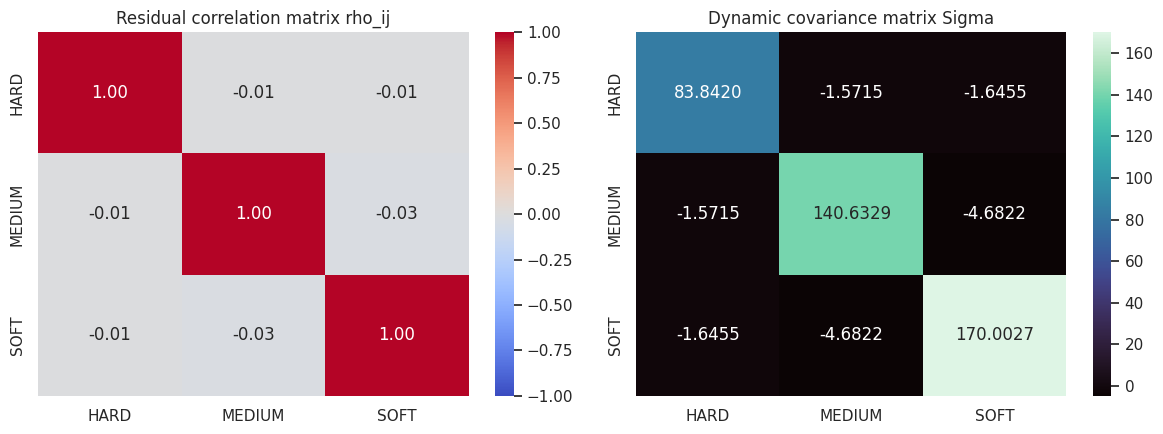

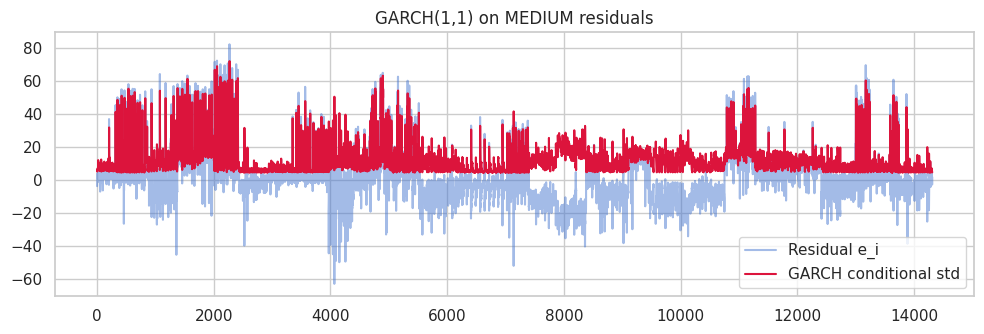

In [14]:
from arch import arch_model

# Fit GARCH(1,1) per compound on residual series e_i
garch_var_by_compound = {}
garch_params = []

for compound in COMPOUNDS:
    residuals = pipeline_df.loc[pipeline_df['Compound'] == compound, 'e_i'].dropna()
    if len(residuals) < 40:
        # fallback: sample variance if too few laps for GARCH
        garch_var_by_compound[compound] = residuals.var() if len(residuals) > 1 else 1e-4
        continue
    try:
        gm = arch_model(residuals.values * 1000, vol='Garch', p=1, q=1, rescale=False)
        gfit = gm.fit(disp='off')
        last_var = (gfit.conditional_volatility.iloc[-1] / 1000) ** 2
        garch_var_by_compound[compound] = last_var
        alpha = gfit.params.get('alpha[1]', np.nan)
        beta = gfit.params.get('beta[1]', np.nan)
        garch_params.append({'compound': compound, 'omega': gfit.params.get('omega', np.nan), 'alpha': alpha, 'beta': beta, 'alpha+beta': alpha + beta})
    except Exception:
        garch_var_by_compound[compound] = residuals.var()

display(pd.DataFrame(garch_params).round(4) if garch_params else pd.DataFrame({'note': ['Used sample variance fallback']}))

# Correlation matrix rho_ij from compound-level mean residuals across drivers
residual_pivot = pipeline_df.pivot_table(index='Driver', columns='Compound', values='e_i', aggfunc='mean')
rho_mat = residual_pivot.corr().reindex(index=COMPOUNDS, columns=COMPOUNDS).fillna(0).values
np.fill_diagonal(rho_mat, 1.0)

# Build dynamic covariance Sigma using GARCH variances on the diagonal
sigma_vec = np.array([np.sqrt(garch_var_by_compound[c]) for c in COMPOUNDS])
Sigma = np.outer(sigma_vec, sigma_vec) * rho_mat

# Ensure positive semi-definite (numerical stability for optimizer)
eigvals, eigvecs = np.linalg.eigh(Sigma)
eigvals = np.clip(eigvals, 1e-8, None)
Sigma = eigvecs @ np.diag(eigvals) @ eigvecs.T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(rho_mat, xticklabels=COMPOUNDS, yticklabels=COMPOUNDS, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Residual correlation matrix rho_ij')
sns.heatmap(Sigma, xticklabels=COMPOUNDS, yticklabels=COMPOUNDS, annot=True, fmt='.4f', cmap='mako', ax=axes[1])
axes[1].set_title('Dynamic covariance matrix Sigma')
plt.tight_layout()
plt.show()

# Plot GARCH conditional volatility for the compound with most laps
top_compound = pipeline_df['Compound'].value_counts().idxmax()
res_top = pipeline_df.loc[pipeline_df['Compound'] == top_compound, 'e_i'].dropna()
if len(res_top) >= 40:
    gdemo = arch_model(res_top.values * 1000, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
    cond_vol = gdemo.conditional_volatility / 1000
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(res_top.values, alpha=0.5, label='Residual e_i')
    ax.plot(cond_vol, color='crimson', label='GARCH conditional std')
    ax.set_title(f'GARCH(1,1) on {top_compound} residuals')
    ax.legend()
    plt.tight_layout()
    plt.show()

### Step 4: Markowitz mean-variance strategy engine

The optimizer balances expected race time against lap-time variance. Unlike finance (maximize return), we **minimize** expected total race time plus a risk penalty. Pit-stop losses enter as a function of how many distinct compounds are used.

$$\min_{\mathbf{x}} \left( \mathbf{\mu}^\top \mathbf{x} + \lambda \, \mathbf{x}^\top \mathbf{\Sigma} \, \mathbf{x} + N_{\text{pits}}(\mathbf{x}) \cdot L_{\text{pit}} \right)$$

Subject to:

$$\sum_{c \in C} x_c = 1, \quad x_c \geq 0$$

$$\sum_{c \in C_{\text{dry}}} \mathbb{I}(x_c > 0) \geq 2 \quad \text{(FIA two-compound rule, dry race)}$$

$$x_c \cdot N \leq A_{\max}(c) \quad \text{(maximum stint thermal threshold)}$$

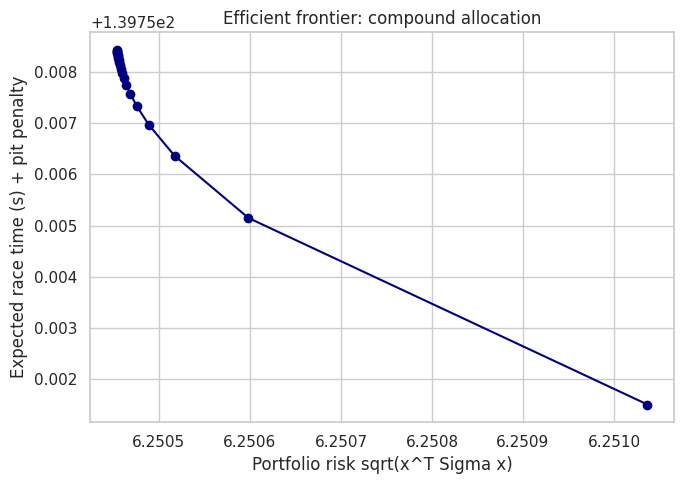

Active compounds: 3, pit stops: 2


,compound,weight,laps_allocated
0,HARD,0.4231,33.0
1,MEDIUM,0.3160,24.7
2,SOFT,0.2609,20.3


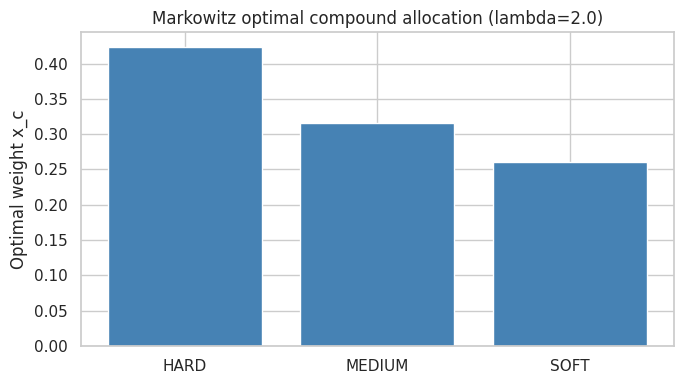

In [15]:
from scipy.optimize import minimize

n_assets = len(COMPOUNDS)
dry_indices = [i for i, c in enumerate(COMPOUNDS) if c in DRY_COMPOUNDS]
a_max_vec = np.array([A_MAX[c] / N_LAPS for c in COMPOUNDS])  # x_c <= A_max(c) / N
MIN_COMPOUND_WEIGHT = 0.05  # at least 5% race distance on a compound to count as "used"

def count_active_compounds(x, threshold=MIN_COMPOUND_WEIGHT):
    # Number of compounds with meaningful allocation (used for pit-stop count)
    return int(np.sum(x >= threshold))

def pit_stop_count(x):
    # N_pits = K - 1 where K is number of distinct compounds used
    return max(0, count_active_compounds(x) - 1)

def race_time_objective(x, mu, sigma, lam, l_pit):
    # Expected lap-time cost + risk penalty + pit-lane transaction cost
    lap_cost = mu @ x
    risk_cost = lam * (x @ sigma @ x)
    pit_cost = pit_stop_count(x) * l_pit / N_LAPS  # spread pit penalty per lap for comparability
    return lap_cost + risk_cost + pit_cost

def optimize_strategy(mu, sigma, lam=2.0, l_pit=L_PIT):
    x0 = np.ones(n_assets) / n_assets
    bounds = [(0.0, 1.0)] * n_assets

    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0},
    ]

    # Maximum stint thermal threshold: x_c * N <= A_max(c)
    for i in range(n_assets):
        constraints.append({'type': 'ineq', 'fun': lambda x, i=i: a_max_vec[i] - x[i]})

    # FIA two-compound rule (dry race): force two largest dry compounds to have minimum weight
    if len(dry_indices) >= 2:
        dry_sorted = sorted(dry_indices, key=lambda i: -mu_0.iloc[i] if i < len(mu_0) else 0)
        top_two_dry = dry_sorted[:2]
        for idx in top_two_dry:
            constraints.append({'type': 'ineq', 'fun': lambda x, idx=idx: x[idx] - MIN_COMPOUND_WEIGHT})

    result = minimize(
        race_time_objective,
        x0,
        args=(mu, sigma, lam, l_pit),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 500, 'ftol': 1e-9},
    )
    return result

# Sweep risk aversion lambda to trace the efficient frontier
lambda_grid = np.linspace(0.5, 10.0, 20)
frontier_time, frontier_risk, frontier_allocations = [], [], []

for lam in lambda_grid:
    res = optimize_strategy(mu_vec, Sigma, lam=lam)
    if res.success:
        x_star = res.x
        frontier_time.append(mu_vec @ x_star + pit_stop_count(x_star) * L_PIT)
        frontier_risk.append(np.sqrt(x_star @ Sigma @ x_star))
        frontier_allocations.append(x_star)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(frontier_risk, frontier_time, marker='o', color='navy')
ax.set_xlabel('Portfolio risk sqrt(x^T Sigma x)')
ax.set_ylabel('Expected race time (s) + pit penalty')
ax.set_title('Efficient frontier: compound allocation')
plt.tight_layout()
plt.show()

# Optimal allocation at default risk aversion
opt_result = optimize_strategy(mu_vec, Sigma, lam=2.0)
x_optimal = opt_result.x
allocation_df = pd.DataFrame({'compound': COMPOUNDS, 'weight': x_optimal})
allocation_df = allocation_df[allocation_df['weight'] > 0.001].sort_values('weight', ascending=False)
allocation_df['laps_allocated'] = (allocation_df['weight'] * N_LAPS).round(1)
print(f'Active compounds: {count_active_compounds(x_optimal)}, pit stops: {pit_stop_count(x_optimal)}')
display(allocation_df.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(allocation_df['compound'], allocation_df['weight'], color='steelblue')
ax.set_ylabel('Optimal weight x_c')
ax.set_title('Markowitz optimal compound allocation (lambda=2.0)')
plt.tight_layout()
plt.show()

### Step 5: Black-Litterman pit-wall views

Historical compound means $\mathbf{\mu}_0$ can be wrong when track conditions change (unexpected graining, temperature shifts). Black-Litterman blends the prior with real-time pit-wall **views** expressed as $P \mathbf{\mu} = Q + \eta$.

Prior:

$$\mathbf{\Pi} \sim \mathcal{N}(\mathbf{\mu}_0, \; \tau \mathbf{\Sigma})$$

Posterior updated mean:

$$\mathbf{\mu}^* = \left[ (\tau \mathbf{\Sigma})^{-1} + \mathbf{P}^\top \mathbf{\Omega}^{-1} \mathbf{P} \right]^{-1} \left[ (\tau \mathbf{\Sigma})^{-1} \mathbf{\mu}_0 + \mathbf{P}^\top \mathbf{\Omega}^{-1} \mathbf{Q} \right]$$

Example view: *"Medium tyres on stint 2 will be 0.4 s slower per lap than baseline."*

,compound,mu_prior,mu_star_BL,delta
0,HARD,91.0422,91.0377,-0.0045
1,MEDIUM,92.9555,93.3553,0.3999
2,SOFT,94.4847,94.4714,-0.0133


,compound,weight_markowitz,weight_black_litterman,shift
0,HARD,0.4231,0.4231,0.0000
1,MEDIUM,0.3160,0.3157,-0.0003
2,SOFT,0.2609,0.2612,0.0003


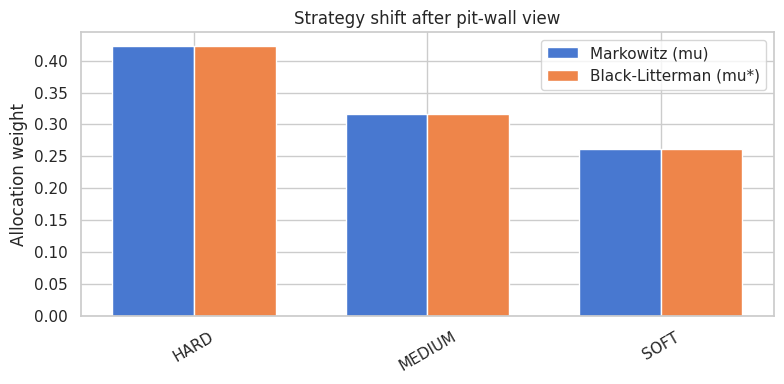

In [16]:
def black_litterman(mu_prior, sigma, P, Q, omega, tau=0.05):
    # Black-Litterman posterior mean mu_star
    sigma = np.asarray(sigma)
    mu_prior = np.asarray(mu_prior).reshape(-1, 1)
    P = np.asarray(P)
    Q = np.asarray(Q).reshape(-1, 1)
    omega = np.asarray(omega)

    tau_sigma_inv = np.linalg.inv(tau * sigma)
    omega_inv = np.linalg.inv(omega)

    middle = np.linalg.inv(tau_sigma_inv + P.T @ omega_inv @ P)
    rhs = tau_sigma_inv @ mu_prior + P.T @ omega_inv @ Q
    mu_star = middle @ rhs
    return mu_star.flatten()

mu_prior = pipeline_df.groupby('Compound')['t_hat'].mean().reindex(COMPOUNDS).values

# Pit-wall view: Medium compound is 0.4 s/lap slower than model baseline due to graining
if 'MEDIUM' in COMPOUNDS:
    med_idx = COMPOUNDS.index('MEDIUM')
    P_view = np.zeros((1, n_assets))
    P_view[0, med_idx] = 1.0
    Q_view = np.array([mu_prior[med_idx] + 0.4])
    Omega_view = np.array([[0.05 ** 2]])  # view uncertainty (5% std)
else:
    # fallback: view on the second compound in the universe
    P_view = np.zeros((1, n_assets))
    P_view[0, 1] = 1.0
    Q_view = np.array([mu_prior[1] + 0.4])
    Omega_view = np.array([[0.05 ** 2]])

mu_star = black_litterman(mu_prior, Sigma, P_view, Q_view, Omega_view, tau=0.05)

bl_compare = pd.DataFrame({
    'compound': COMPOUNDS,
    'mu_prior': mu_prior,
    'mu_star_BL': mu_star,
    'delta': mu_star - mu_prior,
}).round(4)
display(bl_compare)

# Re-optimize with Black-Litterman adjusted means
bl_result = optimize_strategy(mu_star, Sigma, lam=2.0)
x_bl = bl_result.x

comparison = pd.DataFrame({
    'compound': COMPOUNDS,
    'weight_markowitz': x_optimal,
    'weight_black_litterman': x_bl,
}).round(4)
comparison['shift'] = comparison['weight_black_litterman'] - comparison['weight_markowitz']
display(comparison[comparison[['weight_markowitz', 'weight_black_litterman']].max(axis=1) > 0.01])

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(COMPOUNDS))
width = 0.35
ax.bar(x_pos - width/2, x_optimal, width, label='Markowitz (mu)')
ax.bar(x_pos + width/2, x_bl, width, label='Black-Litterman (mu*)')
ax.set_xticks(x_pos)
ax.set_xticklabels(COMPOUNDS, rotation=30)
ax.set_ylabel('Allocation weight')
ax.set_title('Strategy shift after pit-wall view')
ax.legend()
plt.tight_layout()
plt.show()

### Step 6: Model performance analysis

We evaluate three components: (1) LightGBM pace prediction accuracy, (2) GARCH residual diagnostics, and (3) optimizer sensitivity. Together these confirm the pipeline produces reliable inputs for $\mathbf{\mu}^*$ and $\mathbf{\Sigma}$ before strategy allocation.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

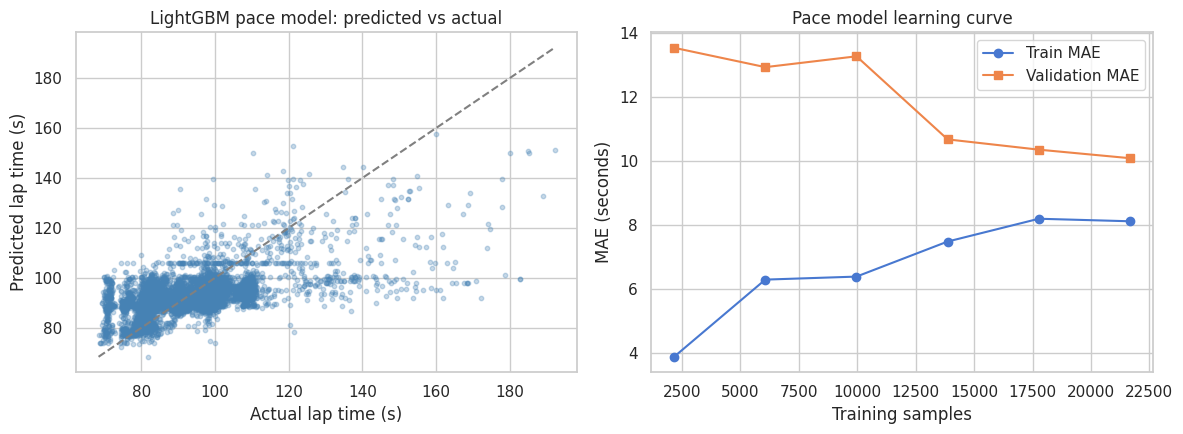

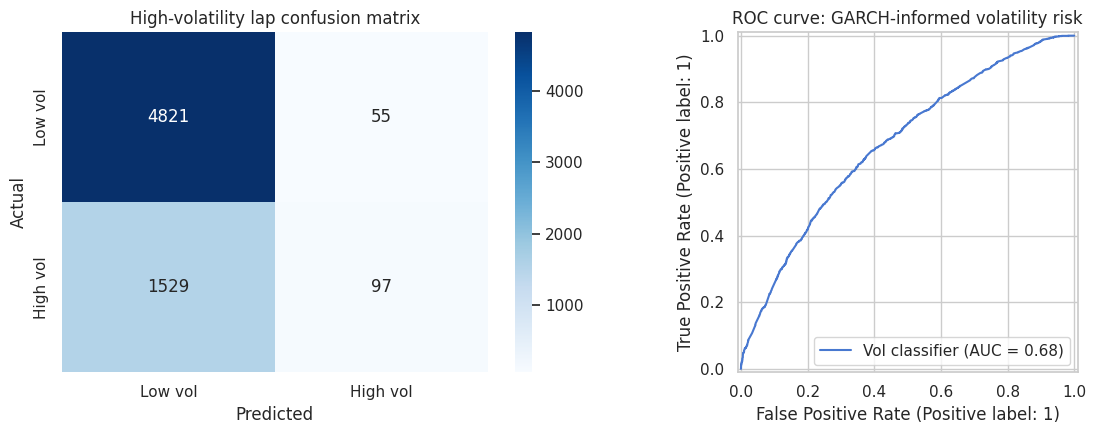

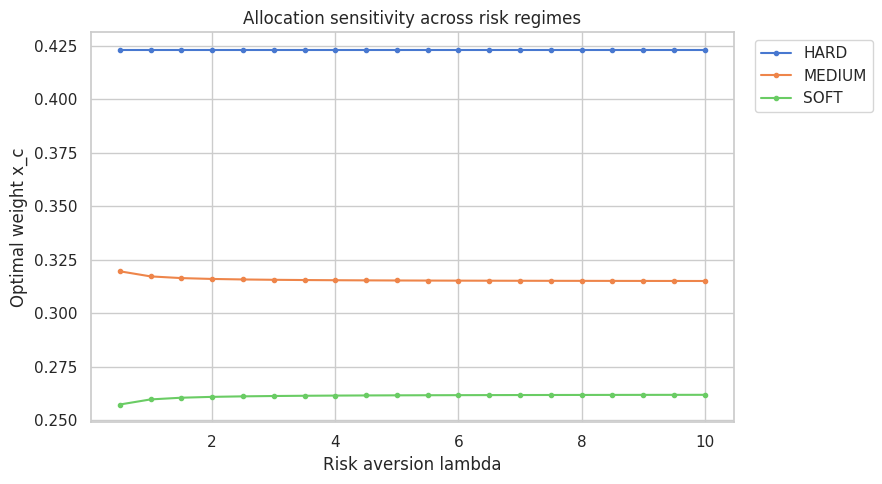

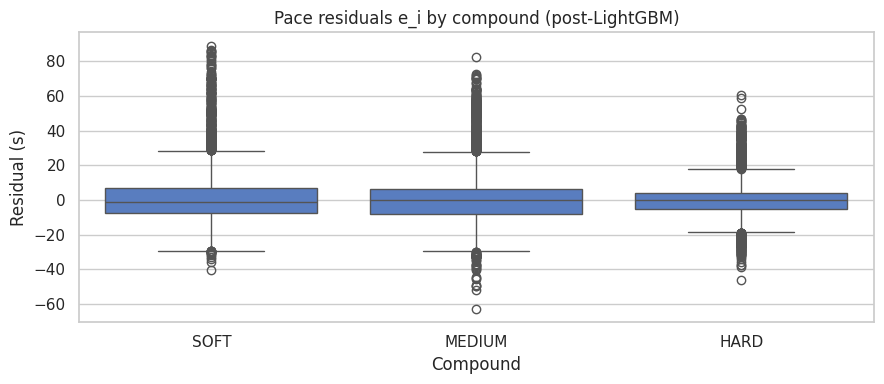

In [17]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, RocCurveDisplay

# --- 6a. Pace model: predicted vs actual and learning curve ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test_p, y_pred_test, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test_p.min(), y_pred_test.min()), max(y_test_p.max(), y_pred_test.max())]
axes[0].plot(lims, lims, '--', color='gray')
axes[0].set_xlabel('Actual lap time (s)')
axes[0].set_ylabel('Predicted lap time (s)')
axes[0].set_title('LightGBM pace model: predicted vs actual')

train_sizes, train_scores, val_scores = learning_curve(
    pace_model, X_pace, y_pace, cv=3, scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1,
)
axes[1].plot(train_sizes, -train_scores.mean(axis=1), marker='o', label='Train MAE')
axes[1].plot(train_sizes, -val_scores.mean(axis=1), marker='s', label='Validation MAE')
axes[1].set_xlabel('Training samples')
axes[1].set_ylabel('MAE (seconds)')
axes[1].set_title('Pace model learning curve')
axes[1].legend()
plt.tight_layout()
plt.show()

# --- 6b. GARCH residual diagnostics: high-volatility classification ---
# Label laps where |e_i| exceeds the 75th percentile as high-volatility events
pipeline_df['high_vol'] = (
    pipeline_df['e_i'].abs() > pipeline_df.groupby('Compound')['e_i'].transform(lambda s: s.abs().quantile(0.75))
).astype(int)

vol_features = ['TyreLife', 'TrackTemp', 'AirTemp', 'traffic_density', 'LapNumber']
X_vol = pipeline_df[vol_features].values
y_vol = pipeline_df['high_vol'].values
X_v_train, X_v_test, y_v_train, y_v_test = train_test_split(X_vol, y_vol, test_size=0.2, random_state=42, stratify=y_vol)

vol_classifier = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
vol_classifier.fit(X_v_train, y_v_train)
vol_preds = vol_classifier.predict(X_v_test)
vol_proba = vol_classifier.predict_proba(X_v_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cm = confusion_matrix(y_v_test, vol_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low vol', 'High vol'], yticklabels=['Low vol', 'High vol'])
axes[0].set_title('High-volatility lap confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
RocCurveDisplay.from_predictions(y_v_test, vol_proba, ax=axes[1], name='Vol classifier')
axes[1].set_title('ROC curve: GARCH-informed volatility risk')
plt.tight_layout()
plt.show()

# --- 6c. Optimizer sensitivity: allocation stability across lambda ---
alloc_matrix = np.array(frontier_allocations)
fig, ax = plt.subplots(figsize=(9, 5))
for i, compound in enumerate(COMPOUNDS):
    ax.plot(lambda_grid[:len(alloc_matrix)], alloc_matrix[:, i], marker='.', label=compound)
ax.set_xlabel('Risk aversion lambda')
ax.set_ylabel('Optimal weight x_c')
ax.set_title('Allocation sensitivity across risk regimes')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 6d. Residual distribution by compound (model diagnostic) ---
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=pipeline_df, x='Compound', y='e_i', ax=ax)
ax.set_title('Pace residuals e_i by compound (post-LightGBM)')
ax.set_ylabel('Residual (s)')
plt.tight_layout()
plt.show()